## Usamos la librería geopy, con la funcion geoceode


In [20]:
import geopy

In [15]:
from geopy.geocoders import Nominatim  # Con esto se localiza un nombre

geolocator = Nominatim(user_agent = 'Bimg')

loc = geolocator.geocode('Estación Biológica de Doñana')
print(loc.address)
print(loc.latitude, loc.longitude)
print(loc.raw)


Estacion Biologica de Doñana CSIC, Calle Leonardo da Vinci, Parque Científico y Tecnológico Cartuja, Triana, Sevilla, Andalucía, 41092, España
37.4119228 -6.0058177
{'place_id': 269538664, 'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright', 'osm_type': 'way', 'osm_id': 121762075, 'lat': '37.4119228', 'lon': '-6.0058177', 'class': 'office', 'type': 'research', 'place_rank': 30, 'importance': 7.680094605931209e-05, 'addresstype': 'office', 'name': 'Estacion Biologica de Doñana CSIC', 'display_name': 'Estacion Biologica de Doñana CSIC, Calle Leonardo da Vinci, Parque Científico y Tecnológico Cartuja, Triana, Sevilla, Andalucía, 41092, España', 'boundingbox': ['37.4117489', '37.4120958', '-6.0061294', '-6.0055060']}


In [18]:
locr = geolocator.reverse('37.4119228 -6.0058177') # con esta función hacemos lo mismo pero al revés a partir de las coordenadas
print(loc.address)
print(loc.latitude, loc.longitude)
print(loc.raw)

Estacion Biologica de Doñana CSIC, Calle Leonardo da Vinci, Parque Científico y Tecnológico Cartuja, Triana, Sevilla, Andalucía, 41092, España
37.4119228 -6.0058177
{'place_id': 269538664, 'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright', 'osm_type': 'way', 'osm_id': 121762075, 'lat': '37.4119228', 'lon': '-6.0058177', 'class': 'office', 'type': 'research', 'place_rank': 30, 'importance': 7.680094605931209e-05, 'addresstype': 'office', 'name': 'Estacion Biologica de Doñana CSIC', 'display_name': 'Estacion Biologica de Doñana CSIC, Calle Leonardo da Vinci, Parque Científico y Tecnológico Cartuja, Triana, Sevilla, Andalucía, 41092, España', 'boundingbox': ['37.4117489', '37.4120958', '-6.0061294', '-6.0055060']}


## PyProj librería para gestionar las proyecciones

In [22]:
# Este código sirve para que nos diga que zona de utm se corresponde
from pyproj import CRS
from pyproj.aoi import AreaOfInterest
from pyproj.database import query_utm_crs_info

utm_crs_list = query_utm_crs_info(
datum_name="WGS 84",
area_of_interest=AreaOfInterest(
west_lon_degree=-93.581543,
south_lat_degree=42.032974,
east_lon_degree=-93.581543,
north_lat_degree=42.032974,
),
)
utm_crs = CRS.from_epsg(utm_crs_list[0].code)
utm_crs

<Projected CRS: EPSG:32615>
Name: WGS 84 / UTM zone 15N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 96°W and 90°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Manitoba; Nunavut; Ontario. Ecuador -Galapagos. Guatemala. Mexico. United States (USA).
- bounds: (-96.0, 0.0, -90.0, 84.0)
Coordinate Operation:
- name: UTM zone 15N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [23]:
# Sirve para pasar de un sistema a otro 
# Te pasa las coordenadas en sistema proyectado partiendo de geográficas

from pyproj import CRS

crs_4326 = CRS.from_epsg(4326)
crs_32629 = CRS.from_epsg(32629)

from pyproj import Transformer
transformer = Transformer.from_crs(crs_4326, crs_32629)

transformer.transform(37.83, -6.45)

(724417.5487037199, 4190017.4801397086)

## Shapely

### Introducción

In [37]:
# Trabajamos con Shapely y definimos puntos, líneas y polígonos

from shapely.geometry import Point, LineString, Polygon

# Vamos a crear una serie de puntos

p1 = Point(2.2,4.2)
p2 = Point(7.2, -25.1)
p3 = Point(9.26, -2.456)
p3D = Point(9.26, -102.456, 5000.57)



In [38]:
# Obtenemos la distancia entre dos puntos
p1.distance(p3D)

106.88940984026435

In [39]:
list(p1.coords)

[(2.2, 4.2)]

In [40]:
# Nos da las coordenadas x e y de un punto
x = p1.x
y = p1.y

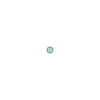

In [42]:
# Se pueden combinar coordenadas de otros puntos
x = p1.x
y = p2.y
p4 = Point(x,y)
p4

LINESTRING (2.2 4.2, 7.2 -25.1, 9.26 -2.456)


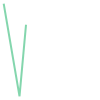

In [49]:
# Crear una línea

ln1 = LineString([p1,p2,p3])
print(ln1)
ln1

In [51]:
# Se pueden hacer comprobaciones topológicas
ln2 = LineString([p1,p2,p4])

ln1 == ln2

False

In [54]:
# Vemos las coordenadas de la línea

list(ln1.coords)

[(2.2, 4.2), (7.2, -25.1), (9.26, -2.456)]

In [67]:
ln_coord = list(ln1.coords)
ln_coord [-1][0]  # Nos da la coordena x o y en función de la posición que le estemos diciendo de la lista  


9.26

In [ ]:
ln1.length # Nos da la longitud de la línea

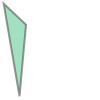

In [68]:
# Hacemos un póligono
pol1 = Polygon([p1,p2,p3])
pol1

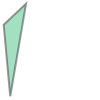

In [71]:
#Create a Polygon based on information from the Shapely points
#Es lo mismo pero con un list comprension
poly2 = Polygon([[p.x * -1, p.y] for p in [point1, point2, point3]]) # -1 coords to flip. 
#Está haciendo una simetría sobre el eje x a ese polígono, la x la multiplica por -1 y la otra queda igual
poly2

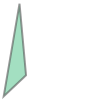

In [72]:
#Create a Polygon based on information from the Shapely points
#Es lo mismo pero con un list comprension
poly2 = Polygon([[p.x, p.y *-1] for p in [point1, point2, point3]]) # -1 coords to flip. 
#Está haciendo una simetría sobre el eje y a ese polígono, la y la multiplica por -1 y la otra queda igual
poly2

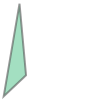

In [74]:
#Create a Polygon based on information from the Shapely points
#Es lo mismo pero con un list comprension
poly2 = Polygon([[p.x + 50, p.y *-1] for p in [point1, point2, point3]]) # -1 coords to flip. 
#Está haciendo una simetría sobre el eje y a ese polígono, la y la multiplica por -1 y la  x el suma 50.
poly2

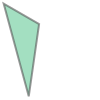

In [75]:
import random #librería para coger valores de manera aleatoria

poly3 = Polygon([[p.x, p.y * random.uniform(0,1)] for p in [point1, point2, point3]]) #* -1 coords to flip
# a la y le da un factor multiplicatorio aleatorio entre 0 y 1
poly3

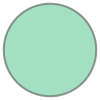

In [77]:
# Hacemos un buffer a un punto

p1buf = p1.buffer(20)
p1buf

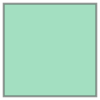

In [82]:

# hacemos un box
from shapely.geometry import box

xmax,xmin = 0, -90
ymax,ymin = 180, 90

este = box(xmin, ymin, xmax, ymax)
este

MULTIPOINT ((2.2 4.2), (7.2 -25.1), (9.26 -2.456))
MULTILINESTRING ((2.2 4.2, 7.2 -25.1), (7.2 -25.1, 9.26 -2.456))


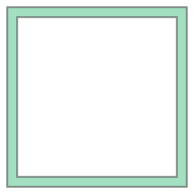

In [86]:
#Import constructors for creating geometry collections
from shapely.geometry import MultiPoint, MultiLineString, MultiPolygon

#Create a MultiPoint object of our points 1,2 and 3
multi_point = MultiPoint([point1, point2, point3])

#It is also possible to pass coordinate tuples inside
multi_point2 = MultiPoint([(2.2, 4.2), (7.2, -25.1), (9.26, -2.456)])

#We can also create a MultiLineString with two lines
line1 = LineString([point1, point2])
line2 = LineString([point2, point3])
multi_line = MultiLineString([line1, line2])

#Print object definitions
print(multi_point)
print(multi_line)

#Let's create the exterior of the western part of the world
west_exterior = [(-180, 90), (-180, -90), (0, -90), (0, 90)]

#Let's create a hole --> remember there can be multiple holes, thus we need to have a list of hole(s).
#Here we have just one.
west_hole = [[(-170, 80), (-170, -80), (-10, -80), (-10, 80)]]

#Create the Polygon
west_poly = Polygon(shell=west_exterior, holes=west_hole)

#Print object definition
#print(west_poly)
west_poly

In [91]:
multi_poly = MultiPolygon([west_poly, este])

#Print object definition
#print(multi_poly)
multi_poly.is_valid

False

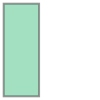

In [93]:
# Generamos un envelope
poly3.envelope


In [104]:
p1 = Point(0,0).buffer(1)
p2 = Point(0.5, 0.5).buffer(1)
p3 = Point(0,1).buffer(1)


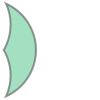

In [106]:
p2.difference(p1).difference(p3)

In [102]:
list(p2.coords)

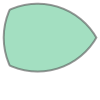

In [108]:
p2.intersection(p1).intersection(p3)

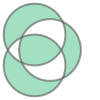

In [110]:
p1.symmetric_difference(p2).symmetric_difference(p3)

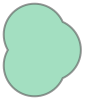

In [112]:
p1.union(p2).union(p3)

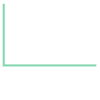

In [114]:
from shapely import affinity
line = LineString([(1, 3), (1, 1), (4, 1)])
rotated_a = affinity.rotate(line, 45)
rotated_b = affinity.rotate(line, -45, origin='centroid')
line

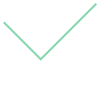

In [117]:
rotated_b

[(0.5, -3.0), (2.0, 7.0), (3.5, -3.0), (0.5, -3.0)]


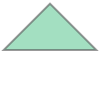

In [120]:
triangle = Polygon([(1, 1), (2, 3), (3, 1)])
triangle_a = affinity.scale(triangle, xfact=1.5, yfact=5)

#Así podemos capturar los puntos de nuestros polígonos
print(triangle_a.exterior.coords[:])

triangle_b = affinity.scale(triangle, xfact=2, origin=(1,1))
triangle_b.exterior.coords[:]

triangle_b

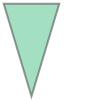

In [122]:
ll = []

for i in triangle_a.exterior.coords[:]:

    ll.append((Point(i).x * -2, Point(i).y * -1))
Polygon(ll)

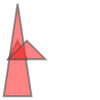

In [123]:
multi_triangle = MultiPolygon([triangle, triangle_a, triangle_b])
multi_triangle

In [129]:
import random
from shapely import affinity
from shapely.geometry import MultiPoint, MultiLineString, MultiPolygon

rotate = []
rotate_s = []

for i in range(0, 360, 30):
    rotated_a = affinity.rotate(triangle, i)
    #triangle_a = affinity.scale(triangle, xfact=1.5, yfact=-1)
    rotated_scalate = affinity.scale(rotated_a, xfact = random.uniform(0,1) , yfact= random.uniform(0,1))
    rotate_s.append(rotated_scalate)
    rotate.append(rotated_a)

    
multitriangle_a = MultiPolygon(rotate)
multitriangle_b = MultiPolygon(rotate_s)


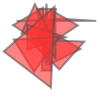

In [131]:
multitriangle_b

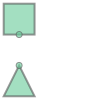

In [132]:
from shapely.ops import nearest_points
from shapely import LineString, Point, GeometryCollection

triangle = Polygon([(0, 0), (1, 0), (0.5, 1), (0, 0)])
square = Polygon([(0, 2), (1, 2), (1, 3), (0, 3), (0, 2)])
rsquare = affinity.rotate(square, 25)
npoints = nearest_points(triangle, square) # busca los puntos más cercanos entre dos geometrías

GeometryCollection([triangle, square, npoints[0], npoints[1]])